In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import pickle
import os

print("Imports done ")

Imports done 


In [3]:
train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("val.csv")
test_df  = pd.read_csv("test.csv")

print(f"Train : {len(train_df):,} rows")
print(f"Val   : {len(val_df):,} rows")
print(f"Test  : {len(test_df):,} rows")
print(f"\nSample input  : {train_df['body_final'].iloc[0]}")
print(f"Sample target : {train_df['title_final'].iloc[0]}")


Train : 28,830 rows
Val   : 3,204 rows
Test  : 3,560 rows

Sample input  : waste money purchased 7 gave away hard watch
Sample target : boring and hard to watchlisten


In [5]:
class Vocabulary:
    """
    Builds a word-to-index mapping from a corpus.

    Special tokens:
        <PAD> = 0  → used to pad sequences to equal length in a batch
        <SOS> = 1  → Start Of Sequence, fed as first token to the decoder
        <EOS> = 2  → End Of Sequence, signals the decoder to stop generating
        <UNK> = 3  → Unknown token, replaces any word not in vocabulary
    """

    PAD_TOKEN = "<PAD>"
    SOS_TOKEN = "<SOS>"
    EOS_TOKEN = "<EOS>"
    UNK_TOKEN = "<UNK>"

    PAD_IDX = 0
    SOS_IDX = 1
    EOS_IDX = 2
    UNK_IDX = 3

    def __init__(self, min_freq: int = 2):
        """
        Args:
            min_freq: words appearing fewer than this many times
                      across the whole corpus are mapped to <UNK>.
                      Keeps vocabulary size manageable.
        """
        self.min_freq = min_freq

        # These are set after calling .build()
        self.word2idx = {}
        self.idx2word = {}
        self.word_freq = Counter()
        self.vocab_size = 0

    # ── tokenizer ──────────────────────────────────────────
    @staticmethod
    def tokenize(text: str) -> list[str]:
        """
        Simple whitespace tokenizer.
        The data is already cleaned so no need for anything fancier.
        Returns a list of lowercase tokens.
        """
        if not isinstance(text, str):
            return []
        return text.lower().strip().split()

    # ── count word frequencies ─────────────────────────────
    def fit(self, sentences: list[str]):
        """
        Count every word in the corpus.
        Call this on BOTH source (body) and target (title) sentences
        so both sides share the same vocabulary.
        (Shared vocab is standard for seq2seq on similar domains.)
        """
        for sentence in sentences:
            tokens = self.tokenize(sentence)
            self.word_freq.update(tokens)
        return self  # allows chaining: vocab.fit(x).fit(y)

    # ── build index mappings ───────────────────────────────
    def build(self):
        """
        After calling .fit(), call .build() to create the
        word2idx and idx2word dictionaries.
        Words below min_freq are dropped (they'll map to <UNK>).
        """
        # Start with special tokens at fixed indices
        self.word2idx = {
            self.PAD_TOKEN: self.PAD_IDX,
            self.SOS_TOKEN: self.SOS_IDX,
            self.EOS_TOKEN: self.EOS_IDX,
            self.UNK_TOKEN: self.UNK_IDX,
        }

        # Add words that meet the frequency threshold
        for word, freq in self.word_freq.most_common():
            if freq >= self.min_freq and word not in self.word2idx:
                self.word2idx[word] = len(self.word2idx)

        # Reverse mapping: index → word (for decoding predictions)
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}
        self.vocab_size = len(self.word2idx)

        print(f"Vocabulary built ✓")
        print(f"  Total unique words seen : {len(self.word_freq):,}")
        print(f"  Words kept (freq ≥ {self.min_freq})  : {self.vocab_size:,}")
        print(f"  Words dropped as <UNK>  : {len(self.word_freq) - (self.vocab_size - 4):,}")
        return self

    # ── convert text ↔ indices ─────────────────────────────
    def encode(self, sentence: str, add_sos: bool = False, add_eos: bool = True) -> list[int]:
        """
        Convert a sentence string into a list of integer indices.

        Args:
            sentence : raw text string
            add_sos  : prepend <SOS> token (used for decoder input)
            add_eos  : append <EOS> token (used for target sequences)

        Returns:
            List of integer token indices.
        """
        tokens = self.tokenize(sentence)
        indices = [self.word2idx.get(t, self.UNK_IDX) for t in tokens]

        if add_sos:
            indices = [self.SOS_IDX] + indices
        if add_eos:
            indices = indices + [self.EOS_IDX]

        return indices

    def decode(self, indices: list[int], skip_special: bool = True) -> str:
        """
        Convert a list of integer indices back into a human-readable string.

        Args:
            indices      : list of token indices (model output)
            skip_special : if True, drops <PAD>, <SOS>, <EOS> from output
        """
        special = {self.PAD_IDX, self.SOS_IDX, self.EOS_IDX}
        words = []
        for idx in indices:
            if skip_special and idx in special:
                continue
            word = self.idx2word.get(idx, self.UNK_TOKEN)
            words.append(word)
            if word == self.EOS_TOKEN and not skip_special:
                break  # stop at end token
        return " ".join(words)

    # ── save / load ────────────────────────────────────────
    def save(self, path: str):
        with open(path, "wb") as f:
            pickle.dump(self, f)
        print(f"Vocabulary saved → {path}")

    @classmethod
    def load(cls, path: str) -> "Vocabulary":
        with open(path, "rb") as f:
            vocab = pickle.load(f)
        print(f"Vocabulary loaded ← {path} ({vocab.vocab_size:,} words)")
        return vocab

In [7]:
vocab = Vocabulary(min_freq=2)

# Fit on both input (body) and output (title) from train set only
vocab.fit(train_df["body_final"].tolist())
vocab.fit(train_df["title_final"].tolist())

# Build the final index mappings
vocab.build()


Vocabulary built ✓
  Total unique words seen : 83,119
  Words kept (freq ≥ 2)  : 33,379
  Words dropped as <UNK>  : 49,744


In [9]:
sample_body  = train_df["body_final"].iloc[0]
sample_title = train_df["title_final"].iloc[0]

print("── Encode/Decode Sanity Check ──────────────────────")
print(f"Original body  : {sample_body}")
print(f"Encoded body   : {vocab.encode(sample_body, add_eos=True)[:10]} ...")

print(f"\nOriginal title : {sample_title}")
encoded_title = vocab.encode(sample_title, add_sos=True, add_eos=True)
print(f"Encoded title  : {encoded_title}")
print(f"Decoded title  : {vocab.decode(encoded_title)}")

# Check special token indices
print(f"\n── Special Token Indices ───────────────────────────")
print(f"<PAD> = {vocab.PAD_IDX}  |  word2idx check: {vocab.word2idx['<PAD>']}")
print(f"<SOS> = {vocab.SOS_IDX}  |  word2idx check: {vocab.word2idx['<SOS>']}")
print(f"<EOS> = {vocab.EOS_IDX}  |  word2idx check: {vocab.word2idx['<EOS>']}")
print(f"<UNK> = {vocab.UNK_IDX}  |  word2idx check: {vocab.word2idx['<UNK>']}")

# Check coverage on val set (words not in vocab → UNK)
def unk_rate(df_col, vocab):
    total, unknowns = 0, 0
    for sentence in df_col:
        tokens = vocab.tokenize(str(sentence))
        for t in tokens:
            total += 1
            if vocab.word2idx.get(t, vocab.UNK_IDX) == vocab.UNK_IDX:
                unknowns += 1
    return unknowns / total * 100 if total > 0 else 0

print(f"\n── OOV (Out-of-Vocab) Rates ────────────────────────")
print(f"Val  body  OOV rate: {unk_rate(val_df['body_final'],  vocab):.2f}%")
print(f"Val  title OOV rate: {unk_rate(val_df['title_final'], vocab):.2f}%")
print(f"Test body  OOV rate: {unk_rate(test_df['body_final'], vocab):.2f}%")
print(f"Test title OOV rate: {unk_rate(test_df['title_final'], vocab):.2f}%")
# Ideally OOV rate < 5%. If higher, lower min_freq.

── Encode/Decode Sanity Check ──────────────────────
Original body  : waste money purchased 7 gave away hard watch
Encoded body   : [120, 47, 139, 934, 230, 131, 75, 98, 2] ...

Original title : boring and hard to watchlisten
Encoded title  : [1, 118, 56, 75, 63, 3, 2]
Decoded title  : boring and hard to <UNK>

── Special Token Indices ───────────────────────────
<PAD> = 0  |  word2idx check: 0
<SOS> = 1  |  word2idx check: 1
<EOS> = 2  |  word2idx check: 2
<UNK> = 3  |  word2idx check: 3

── OOV (Out-of-Vocab) Rates ────────────────────────
Val  body  OOV rate: 6.70%
Val  title OOV rate: 3.38%
Test body  OOV rate: 6.69%
Test title OOV rate: 3.34%


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from collections import Counter

In [13]:
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a1a",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#ddd",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#eee",
    "grid.color":       "#2a2a2a",
    "grid.linewidth":   0.8,
})
ACCENT = ["#4fc3f7", "#81c784", "#ffb74d", "#e57373", "#ce93d8"]

print("Visualization setup done ✓")

Visualization setup done ✓


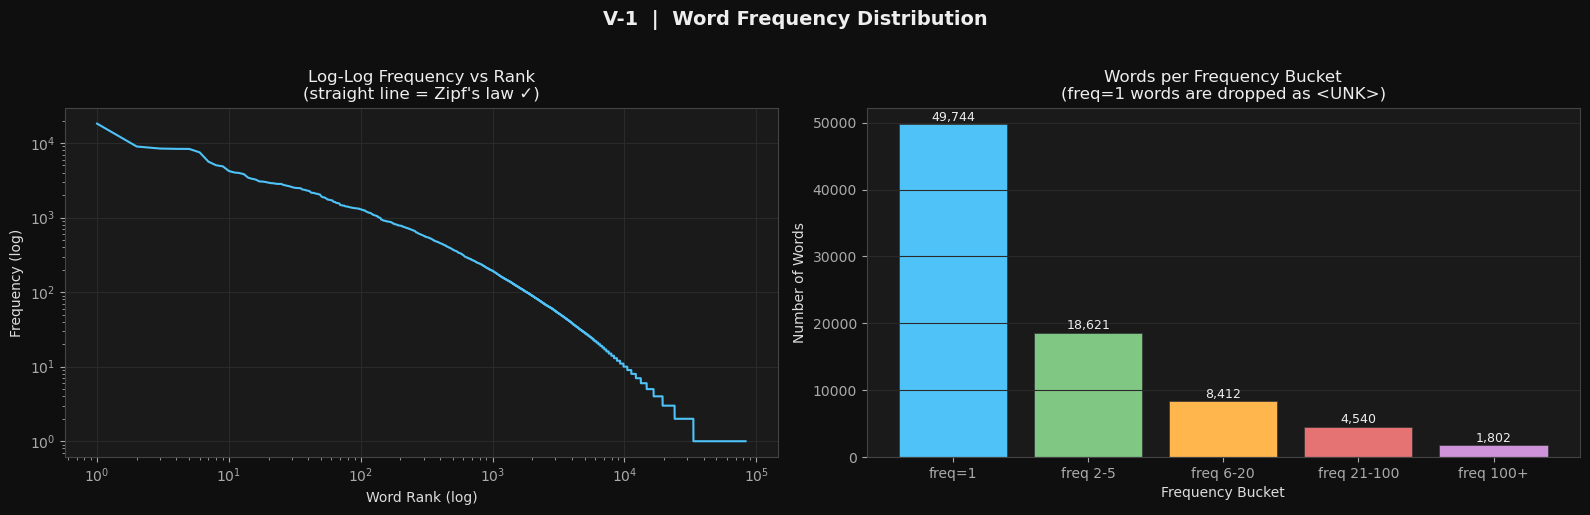

  Words with freq=1 (excluded): 49,744
  Words kept in vocab          : 33,375  (+ 4 special tokens)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("V-1  |  Word Frequency Distribution", fontsize=14, fontweight="bold", y=1.02)

freqs = sorted(vocab.word_freq.values(), reverse=True)

# Left: log-log plot (should be close to a straight line = Zipf's law holds)
ax = axes[0]
ax.plot(range(1, len(freqs)+1), freqs, color=ACCENT[0], linewidth=1.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Word Rank (log)")
ax.set_ylabel("Frequency (log)")
ax.set_title("Log-Log Frequency vs Rank\n(straight line = Zipf's law ✓)")
ax.grid(True)

# Right: frequency bucket histogram
ax = axes[1]
buckets = {"freq=1": 0, "freq 2-5": 0, "freq 6-20": 0, "freq 21-100": 0, "freq 100+": 0}
for f in vocab.word_freq.values():
    if f == 1:               buckets["freq=1"]     += 1
    elif f <= 5:             buckets["freq 2-5"]   += 1
    elif f <= 20:            buckets["freq 6-20"]  += 1
    elif f <= 100:           buckets["freq 21-100"]+= 1
    else:                    buckets["freq 100+"]  += 1

bars = ax.bar(buckets.keys(), buckets.values(), color=ACCENT[:5], edgecolor="#333", linewidth=0.5)
ax.set_xlabel("Frequency Bucket")
ax.set_ylabel("Number of Words")
ax.set_title("Words per Frequency Bucket\n(freq=1 words are dropped as <UNK>)")
for bar, val in zip(bars, buckets.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}", ha="center", va="bottom", fontsize=9, color="#eee")
ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("v1_word_frequency.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print(f"  Words with freq=1 (excluded): {buckets['freq=1']:,}")
print(f"  Words kept in vocab          : {vocab.vocab_size - 4:,}  (+ 4 special tokens)")

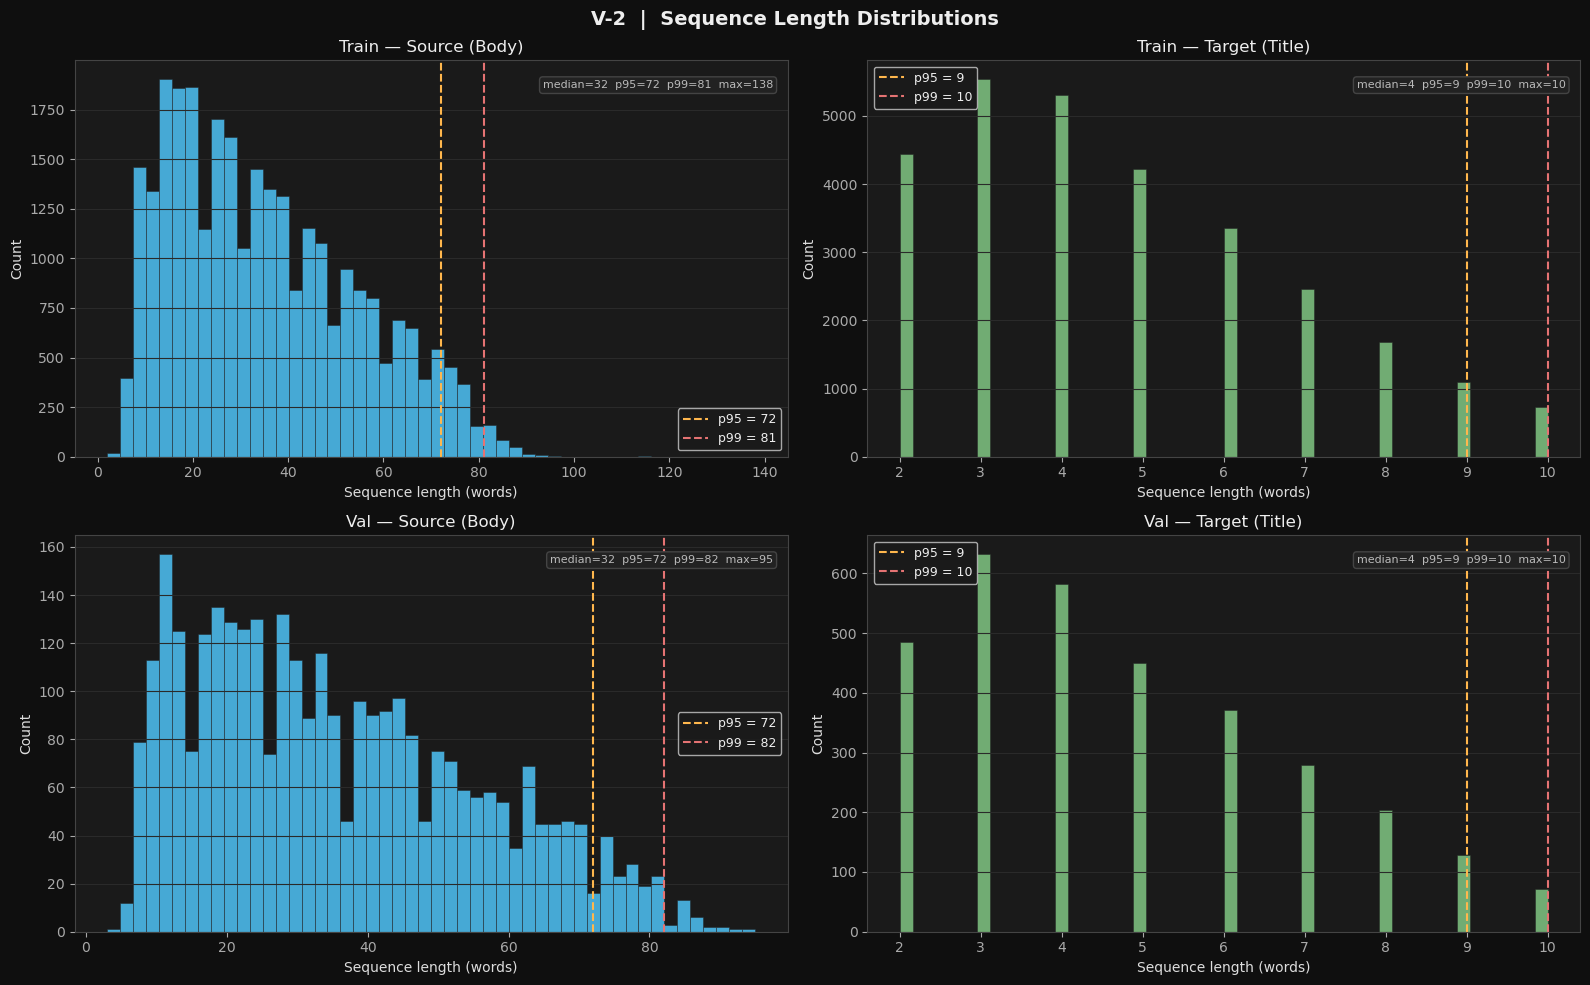


  ── Recommended values for Step 2 ──────────────────
  MAX_SRC_LEN = 81   (covers 99% of body lengths)
  MAX_TGT_LEN = 10   (covers 99% of title lengths)


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("V-2  |  Sequence Length Distributions", fontsize=14, fontweight="bold")

splits = [("Train", train_df), ("Val", val_df)]
cols   = [("body_final", "Source (Body)"), ("title_final", "Target (Title)")]

for row, (split_name, df) in enumerate(splits):
    for col, (col_name, col_label) in enumerate(cols):
        ax = axes[row][col]
        lengths = df[col_name].dropna().apply(lambda x: len(str(x).split()))

        ax.hist(lengths, bins=50, color=ACCENT[col], edgecolor="#222", linewidth=0.4, alpha=0.85)

        p50  = int(np.percentile(lengths, 50))
        p95  = int(np.percentile(lengths, 95))
        p99  = int(np.percentile(lengths, 99))
        pmax = int(lengths.max())

        ax.axvline(p95, color="#ffb74d", linestyle="--", linewidth=1.5, label=f"p95 = {p95}")
        ax.axvline(p99, color="#e57373", linestyle="--", linewidth=1.5, label=f"p99 = {p99}")

        ax.set_title(f"{split_name} — {col_label}")
        ax.set_xlabel("Sequence length (words)")
        ax.set_ylabel("Count")
        ax.legend(fontsize=9)
        ax.grid(True, axis="y")

        ax.text(0.98, 0.95,
                f"median={p50}  p95={p95}  p99={p99}  max={pmax}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=8, color="#bbb",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#222", edgecolor="#444"))

plt.tight_layout()
plt.savefig("v2_sequence_lengths.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

# Print recommended max lengths for Step 2
body_lengths  = train_df["body_final"].dropna().apply(lambda x: len(str(x).split()))
title_lengths = train_df["title_final"].dropna().apply(lambda x: len(str(x).split()))
print(f"\n  ── Recommended values for Step 2 ──────────────────")
print(f"  MAX_SRC_LEN = {int(np.percentile(body_lengths, 99))}   (covers 99% of body lengths)")
print(f"  MAX_TGT_LEN = {int(np.percentile(title_lengths, 99))}   (covers 99% of title lengths)")

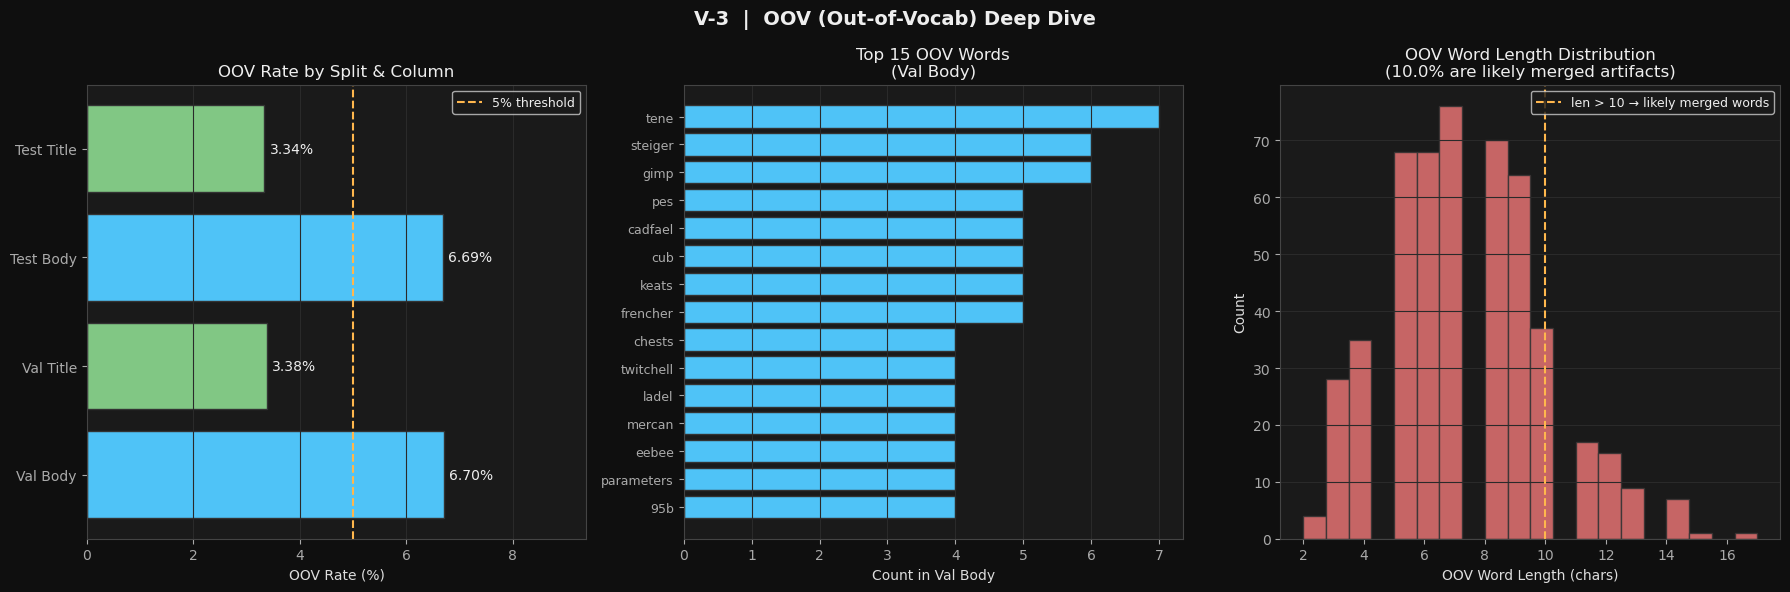

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("V-3  |  OOV (Out-of-Vocab) Deep Dive", fontsize=14, fontweight="bold")

def get_oov_words(series, vocab, top_n=20):
    oov_counter = Counter()
    for sentence in series:
        for token in vocab.tokenize(str(sentence)):
            if vocab.word2idx.get(token, vocab.UNK_IDX) == vocab.UNK_IDX:
                oov_counter[token] += 1
    return oov_counter.most_common(top_n)

# OOV rate by split
ax = axes[0]
splits_info = {
    "Val Body":   unk_rate(val_df["body_final"],   vocab),
    "Val Title":  unk_rate(val_df["title_final"],  vocab),
    "Test Body":  unk_rate(test_df["body_final"],  vocab),
    "Test Title": unk_rate(test_df["title_final"], vocab),
}
colors = [ACCENT[0] if "Body" in k else ACCENT[1] for k in splits_info]
bars = ax.barh(list(splits_info.keys()), list(splits_info.values()),
               color=colors, edgecolor="#333")
ax.axvline(5, color="#ffb74d", linestyle="--", linewidth=1.5, label="5% threshold")
for bar, val in zip(bars, splits_info.values()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}%", va="center", fontsize=10)
ax.set_xlabel("OOV Rate (%)")
ax.set_title("OOV Rate by Split & Column")
ax.legend(fontsize=9)
ax.grid(True, axis="x")
ax.set_xlim(0, max(splits_info.values()) * 1.4)

# Top OOV words in val body
ax = axes[1]
top_oov = get_oov_words(val_df["body_final"], vocab, top_n=15)
if top_oov:
    words, counts = zip(*top_oov)
    bars = ax.barh(range(len(words)), counts, color=ACCENT[0], edgecolor="#333")
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Count in Val Body")
    ax.set_title("Top 15 OOV Words\n(Val Body)")
    ax.grid(True, axis="x")

# OOV word length distribution (merged/artifact words tend to be very long)
ax = axes[2]
all_oov_val = get_oov_words(val_df["body_final"], vocab, top_n=500)
oov_word_lens = [len(w) for w, _ in all_oov_val]
if oov_word_lens:
    ax.hist(oov_word_lens, bins=20, color=ACCENT[3], edgecolor="#333", alpha=0.85)
    ax.axvline(10, color="#ffb74d", linestyle="--", linewidth=1.5,
               label="len > 10 → likely merged words")
    merged_pct = sum(1 for l in oov_word_lens if l > 10) / len(oov_word_lens) * 100
    ax.set_xlabel("OOV Word Length (chars)")
    ax.set_ylabel("Count")
    ax.set_title(f"OOV Word Length Distribution\n({merged_pct:.1f}% are likely merged artifacts)")
    ax.legend(fontsize=9)
    ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("v3_oov_analysis.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

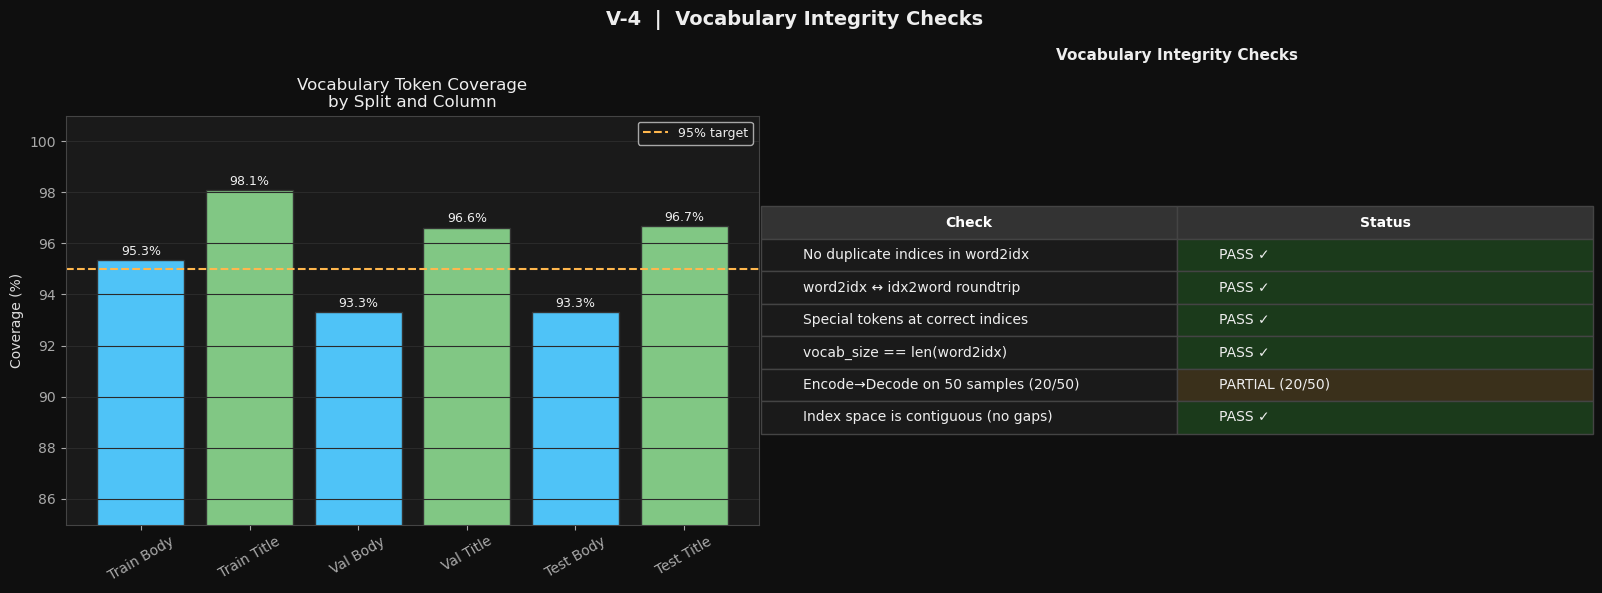


── Integrity Check Results ────────────────────────────
  ✓ No duplicate indices in word2idx                    PASS ✓
  ✓ word2idx ↔ idx2word roundtrip                       PASS ✓
  ✓ Special tokens at correct indices                   PASS ✓
  ✓ vocab_size == len(word2idx)                         PASS ✓
  ✗ Encode→Decode on 50 samples (20/50)                 PARTIAL (20/50)
  ✓ Index space is contiguous (no gaps)                 PASS ✓

  ✅ All checks passed — safe to save vocabulary.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("V-4  |  Vocabulary Integrity Checks", fontsize=14, fontweight="bold")

# Left: bar chart — vocab coverage % per split
ax = axes[0]

def coverage_stats(series, vocab):
    total = known = 0
    for sentence in series:
        for token in vocab.tokenize(str(sentence)):
            total += 1
            if vocab.word2idx.get(token, vocab.UNK_IDX) != vocab.UNK_IDX:
                known += 1
    return (known / total * 100) if total > 0 else 0

coverage = {
    "Train Body":  coverage_stats(train_df["body_final"],  vocab),
    "Train Title": coverage_stats(train_df["title_final"], vocab),
    "Val Body":    coverage_stats(val_df["body_final"],    vocab),
    "Val Title":   coverage_stats(val_df["title_final"],  vocab),
    "Test Body":   coverage_stats(test_df["body_final"],   vocab),
    "Test Title":  coverage_stats(test_df["title_final"],  vocab),
}
colors = [ACCENT[0] if "Body" in k else ACCENT[1] for k in coverage]
bars = ax.bar(list(coverage.keys()), list(coverage.values()), color=colors, edgecolor="#333")
ax.axhline(95, color="#ffb74d", linestyle="--", linewidth=1.5, label="95% target")
ax.set_ylim(85, 101)
ax.set_ylabel("Coverage (%)")
ax.set_title("Vocabulary Token Coverage\nby Split and Column")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=9)
ax.grid(True, axis="y")
for bar, val in zip(bars, coverage.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

# Right: integrity check summary table rendered as text
ax = axes[1]
ax.axis("off")

checks = []

# Check 1: No duplicate indices in word2idx
dup_idx = len(vocab.word2idx) != len(set(vocab.word2idx.values()))
checks.append(("No duplicate indices in word2idx",    "PASS ✓" if not dup_idx     else "FAIL ✗"))

# Check 2: word2idx and idx2word are inverses
roundtrip_ok = all(vocab.idx2word[idx] == word for word, idx in vocab.word2idx.items())
checks.append(("word2idx ↔ idx2word roundtrip",       "PASS ✓" if roundtrip_ok    else "FAIL ✗"))

# Check 3: Special token positions
sp_ok = (vocab.word2idx.get("<PAD>") == 0 and
         vocab.word2idx.get("<SOS>") == 1 and
         vocab.word2idx.get("<EOS>") == 2 and
         vocab.word2idx.get("<UNK>") == 3)
checks.append(("Special tokens at correct indices",   "PASS ✓" if sp_ok           else "FAIL ✗"))

# Check 4: vocab_size matches actual dict length
size_ok = vocab.vocab_size == len(vocab.word2idx)
checks.append(("vocab_size == len(word2idx)",         "PASS ✓" if size_ok         else "FAIL ✗"))

# Check 5: encode→decode roundtrip on 50 random samples
rtrip = 0
for sentence in train_df["body_final"].sample(50, random_state=42):
    enc = vocab.encode(sentence, add_sos=False, add_eos=False)
    dec = vocab.decode(enc, skip_special=True)
    # Roundtrip is successful if all known words come back the same
    orig_known = [t for t in vocab.tokenize(sentence)
                  if vocab.word2idx.get(t, vocab.UNK_IDX) != vocab.UNK_IDX]
    dec_words  = dec.split()
    if orig_known == dec_words:
        rtrip += 1
checks.append((f"Encode→Decode on 50 samples ({rtrip}/50)", "PASS ✓" if rtrip == 50 else f"PARTIAL ({rtrip}/50)"))

# Check 6: All indices are contiguous (no gaps)
all_indices = sorted(vocab.idx2word.keys())
contiguous  = all_indices == list(range(vocab.vocab_size))
checks.append(("Index space is contiguous (no gaps)", "PASS ✓" if contiguous      else "FAIL ✗"))

col_labels = ["Check", "Status"]
table_data = checks
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="left"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.2)

for (row, col), cell in table.get_celld().items():
    cell.set_facecolor("#1a1a1a")
    cell.set_edgecolor("#444")
    cell.set_text_props(color="#eee")
    if row == 0:
        cell.set_facecolor("#333")
        cell.set_text_props(color="#fff", fontweight="bold")
    if col == 1 and row > 0:
        status = table_data[row-1][1]
        if "PASS" in status:   cell.set_facecolor("#1b3a1b")
        elif "FAIL" in status: cell.set_facecolor("#3a1b1b")
        else:                  cell.set_facecolor("#3a301b")

ax.set_title("Vocabulary Integrity Checks", fontsize=11, fontweight="bold", pad=40)

plt.tight_layout()
plt.savefig("v4_integrity_checks.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

# Print all checks to console as well
print("\n── Integrity Check Results ────────────────────────────")
all_pass = True
for check, result in checks:
    print(f"  {'✓' if 'PASS' in result else '✗'} {check:50s}  {result}")
    if "FAIL" in result:
        all_pass = False

print(f"\n{'  ✅ All checks passed — safe to save vocabulary.' if all_pass else '  ⚠️  Fix the failing checks before saving.'}")

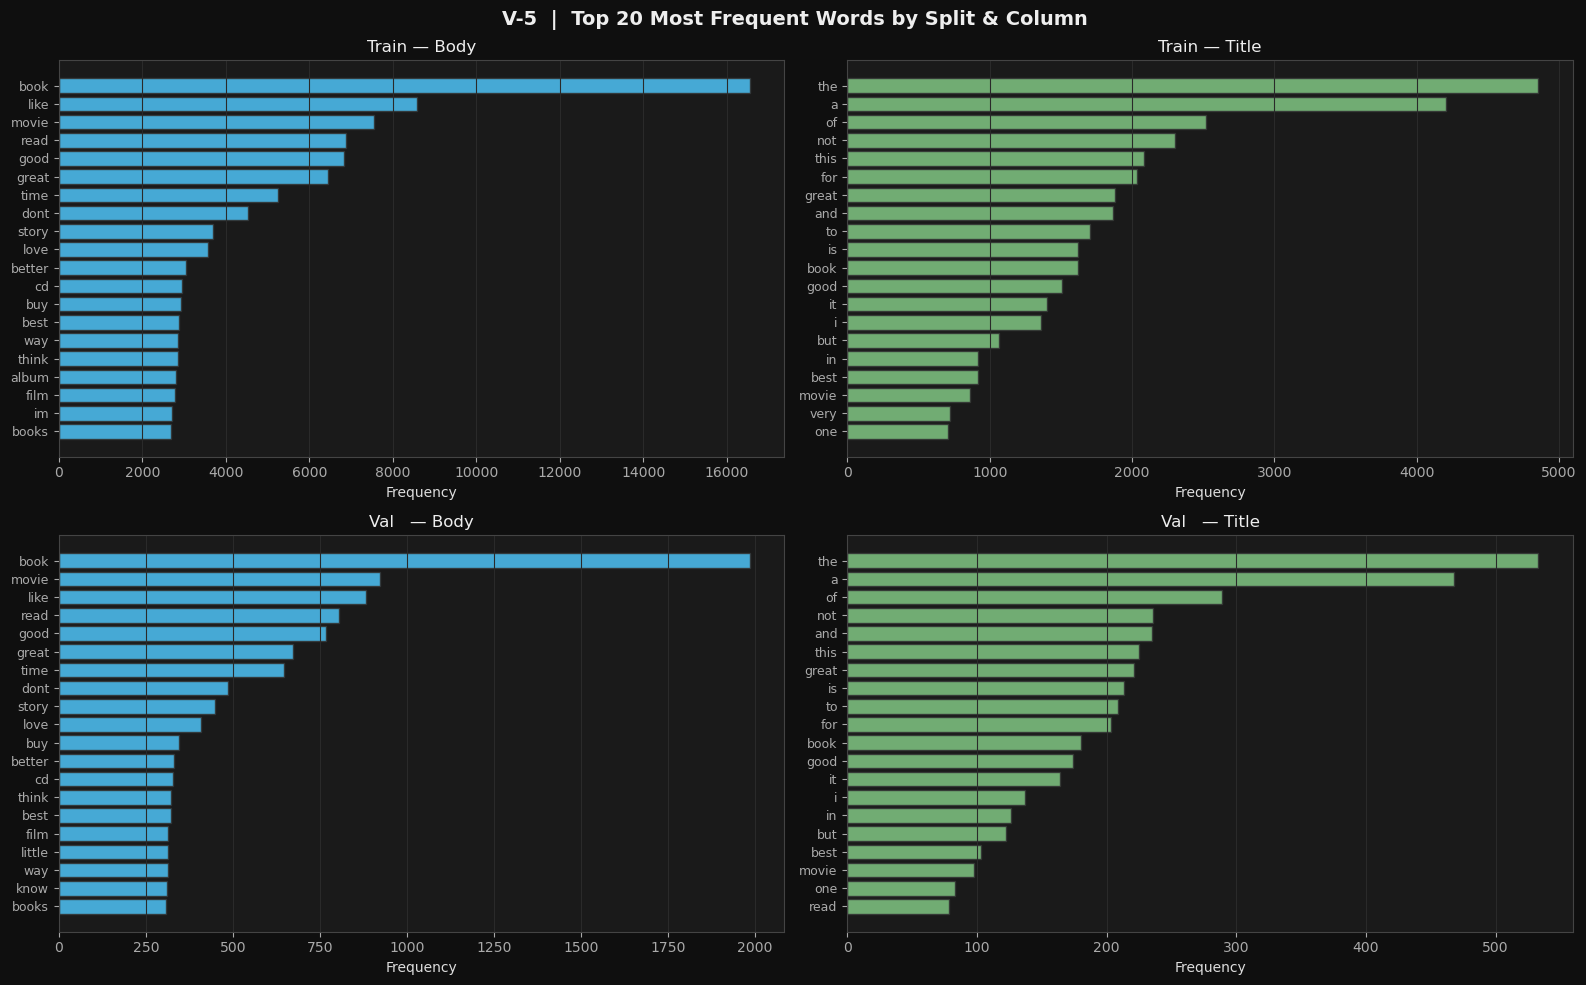


✅  All visualizations complete.
   If all checks passed → run Cell 1-F to save the vocabulary.
   Then move on to → Step 2: Dataset & DataLoader


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("V-5  |  Top 20 Most Frequent Words by Split & Column", fontsize=14, fontweight="bold")

subsets = [
    (axes[0][0], train_df["body_final"],  "Train — Body",  ACCENT[0]),
    (axes[0][1], train_df["title_final"], "Train — Title", ACCENT[1]),
    (axes[1][0], val_df["body_final"],    "Val   — Body",  ACCENT[0]),
    (axes[1][1], val_df["title_final"],   "Val   — Title", ACCENT[1]),
]

for ax, series, title, color in subsets:
    counter = Counter()
    for sentence in series:
        counter.update(vocab.tokenize(str(sentence)))
    # Exclude special tokens from top words
    special_words = {"<pad>", "<sos>", "<eos>", "<unk>"}
    top20 = [(w, c) for w, c in counter.most_common(25) if w not in special_words][:20]
    words, counts = zip(*top20)
    ax.barh(range(len(words)), counts, color=color, edgecolor="#333", alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Frequency")
    ax.set_title(title)
    ax.grid(True, axis="x")

plt.tight_layout()
plt.savefig("v5_top_words.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

print("\n✅  All visualizations complete.")
print("   If all checks passed → run Cell 1-F to save the vocabulary.")
print("   Then move on to → Step 2: Dataset & DataLoader")

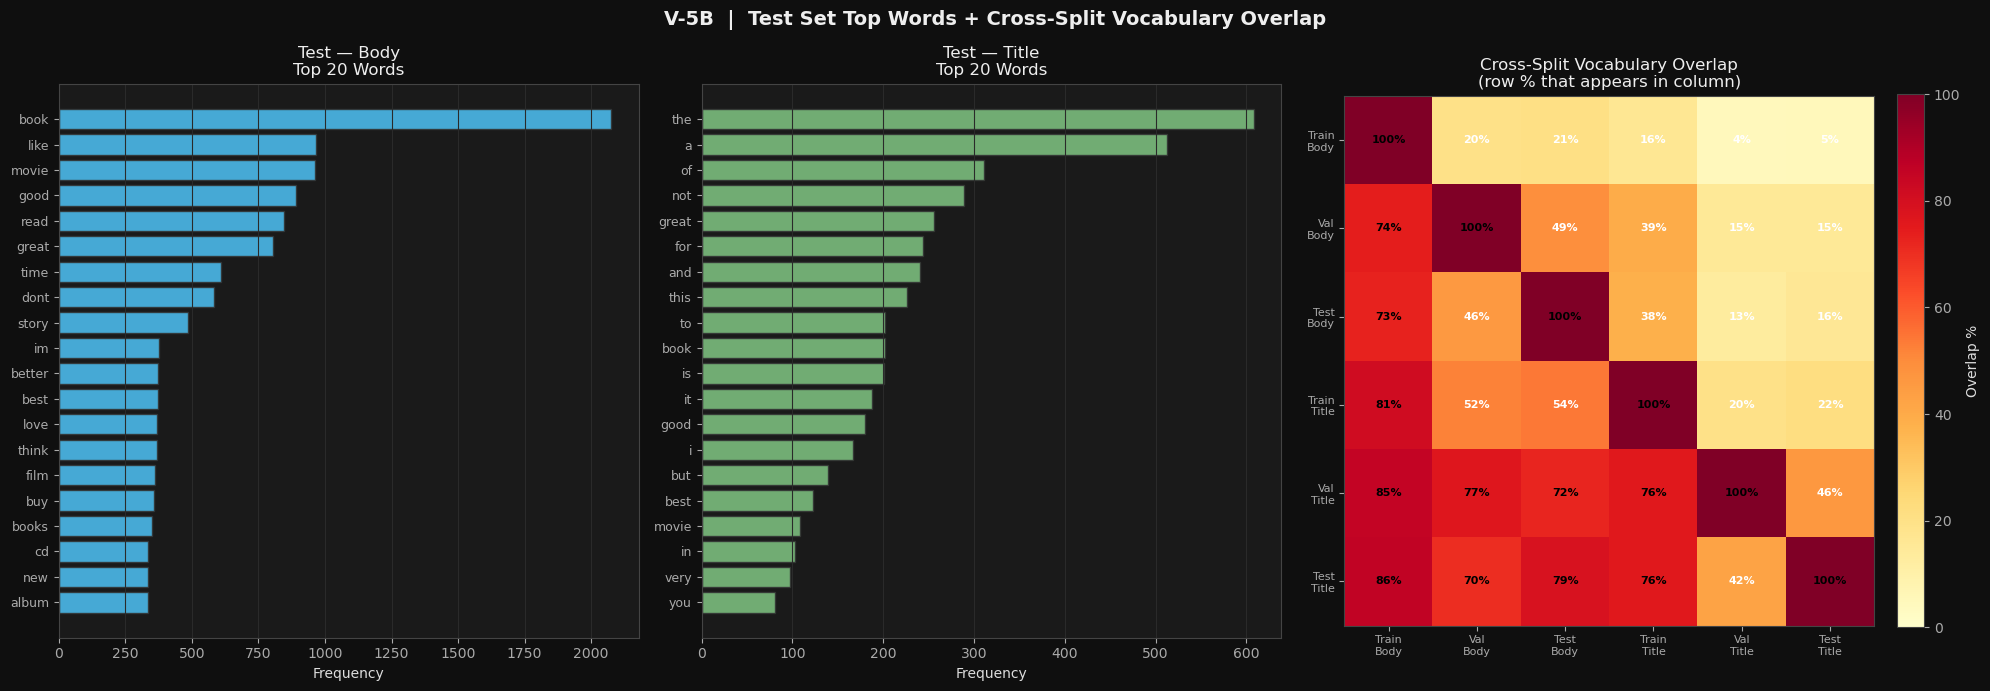


── Cross-Split Overlap Summary ──────────────────────────
  Train Body → Val  Body  overlap : 74.1%
  Train Body → Test Body  overlap : 72.7%
  Val  Body  → Test Body  overlap : 45.9%

  Train Title → Val  Title overlap : 75.8%
  Train Title → Test Title overlap : 75.7%

  If Val/Test → Train overlap is high (>70%) → splits are consistent ✓
  If it's low → your splits may be non-random or domain-shifted ⚠️


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("V-5B  |  Test Set Top Words + Cross-Split Vocabulary Overlap", fontsize=14, fontweight="bold")

# Left: Test Body top words
ax = axes[0]
counter = Counter()
for sentence in test_df["body_final"]:
    counter.update(vocab.tokenize(str(sentence)))
top20 = [(w, c) for w, c in counter.most_common(25) if w not in {"<pad>","<sos>","<eos>","<unk>"}][:20]
words, counts = zip(*top20)
ax.barh(range(len(words)), counts, color=ACCENT[0], edgecolor="#333", alpha=0.85)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Test — Body\nTop 20 Words")
ax.grid(True, axis="x")

# Middle: Test Title top words
ax = axes[1]
counter = Counter()
for sentence in test_df["title_final"]:
    counter.update(vocab.tokenize(str(sentence)))
top20 = [(w, c) for w, c in counter.most_common(25) if w not in {"<pad>","<sos>","<eos>","<unk>"}][:20]
words, counts = zip(*top20)
ax.barh(range(len(words)), counts, color=ACCENT[1], edgecolor="#333", alpha=0.85)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Test — Title\nTop 20 Words")
ax.grid(True, axis="x")

# Right: Cross-split vocabulary overlap heatmap
# For each pair of splits, what % of unique words in split A also appear in split B?
ax = axes[2]

def unique_words(series):
    words = set()
    for sentence in series:
        words.update(vocab.tokenize(str(sentence)))
    return words

split_words = {
    "Train\nBody":  unique_words(train_df["body_final"]),
    "Val\nBody":    unique_words(val_df["body_final"]),
    "Test\nBody":   unique_words(test_df["body_final"]),
    "Train\nTitle": unique_words(train_df["title_final"]),
    "Val\nTitle":   unique_words(val_df["title_final"]),
    "Test\nTitle":  unique_words(test_df["title_final"]),
}

labels = list(split_words.keys())
n = len(labels)
overlap_matrix = np.zeros((n, n))

for i, (name_i, words_i) in enumerate(split_words.items()):
    for j, (name_j, words_j) in enumerate(split_words.items()):
        # % of words in split_i that also appear in split_j
        if len(words_i) > 0:
            overlap_matrix[i][j] = len(words_i & words_j) / len(words_i) * 100

im = ax.imshow(overlap_matrix, cmap="YlOrRd", vmin=0, vmax=100)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title("Cross-Split Vocabulary Overlap\n(row % that appears in column)")

for i in range(n):
    for j in range(n):
        val = overlap_matrix[i][j]
        color = "black" if val > 60 else "white"
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=8, color=color, fontweight="bold")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Overlap %")

plt.tight_layout()
plt.savefig("v5b_test_words_overlap.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

# ── What to look for in the overlap heatmap: ──────────────────
# Train Body → Val Body and Train Body → Test Body should both
# be high (>70%). If test has very low overlap with train, your
# model will struggle because it's seeing mostly unknown context.
# The diagonal is always 100% (a split overlaps perfectly with itself).

print("\n── Cross-Split Overlap Summary ──────────────────────────")
train_body_idx = 0  # "Train\nBody"
val_body_idx   = 1
test_body_idx  = 2
print(f"  Train Body → Val  Body  overlap : {overlap_matrix[val_body_idx][train_body_idx]:.1f}%")
print(f"  Train Body → Test Body  overlap : {overlap_matrix[test_body_idx][train_body_idx]:.1f}%")
print(f"  Val  Body  → Test Body  overlap : {overlap_matrix[test_body_idx][val_body_idx]:.1f}%")
print()
print(f"  Train Title → Val  Title overlap : {overlap_matrix[3+1][3+0]:.1f}%")
print(f"  Train Title → Test Title overlap : {overlap_matrix[3+2][3+0]:.1f}%")
print()
print("  If Val/Test → Train overlap is high (>70%) → splits are consistent ✓")
print("  If it's low → your splits may be non-random or domain-shifted ⚠️")


In [27]:
vocab.save("vocabulary.pkl")

# To reload in another notebook session:
# vocab = Vocabulary.load("vocabulary.pkl")

print("\n✅  Step 1 Complete — Vocabulary is ready.")
print(f"   vocab_size = {vocab.vocab_size:,}")
print(f"   Next → Step 2: Dataset & DataLoader")

Vocabulary saved → vocabulary.pkl

✅  Step 1 Complete — Vocabulary is ready.
   vocab_size = 33,379
   Next → Step 2: Dataset & DataLoader
